In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/.julia/dev/Traulls/benchmark`


In [2]:
using Plots, BenchmarkProfiles, DataFrames, Printf, ForwardDiff, CSV

In [3]:
run_experiments = false # Set to true to run the numerical experiments in the notebook
run_experiments && include("run_experiments.jl")

false

# Comparing TRAULLS with different Hessian approximations

In [4]:
# Form results dataframes

df_gn = CSV.read("results/traulls_gn.csv", DataFrame)
df_bfgs = CSV.read("results/traulls_bfgs.csv", DataFrame)
df_sr1 = CSV.read("results/traulls_sr1.csv", DataFrame)
df_hybrid_bfgs = CSV.read("results/traulls_hybrid_bfgs.csv", DataFrame)
df_hybrid_sr1 = CSV.read("results/traulls_hybrid_sr1.csv", DataFrame);

In [5]:
function make_traulls_table(metric, solvers)
    
    T = zeros(nrow(solvers[1]), size(solvers,1))
    
    for (j, df) in enumerate(solvers)
        for (i, row) in enumerate(eachrow(df))
            T[i,j] = row[:status] == "first_order_critical" ? row[metric] : Inf
        end
    end
    
    return T
end

make_traulls_table (generic function with 1 method)

## All Hessians

In [6]:
# Comparison of Hessian approximations
solvers_df = [df_gn, df_bfgs, df_sr1, df_hybrid_bfgs, df_hybrid_sr1]
solvers = ["Gauss-Newton", "BFGS", "SR1", "HybridBFGS", "HybridSR1"];

In [7]:
T = make_traulls_table(:elapsed_time, solvers_df)
plt_time = performance_profile(PlotsBackend(), T, solvers, 
        linestyles = [:solid, :solid, :solid, :dash, :dot], lw=2, 
    legend=:bottomright, xaxis = "τ (logscale)", yaxis = "ρ(τ)", title = "elapsed time")

T = make_traulls_table(:nouter_iter, solvers_df)
plt_nouter = performance_profile(PlotsBackend(), T, solvers, 
        linestyles = [:solid, :solid, :solid, :dash, :dot], lw=2,
    legend=:bottomright, xaxis = "τ (logscale)", yaxis = "ρ(τ)", title = "number of outer iterations")

T = make_traulls_table(:ninner_iter, solvers_df)
plt_ninner = performance_profile(PlotsBackend(), T, solvers, 
        linestyles = [:solid, :solid, :solid, :dash, :dot], lw=2,
    legend=:bottomright, xaxis = "τ (logscale)", yaxis = "ρ(τ)", title = "number of inner iterations");

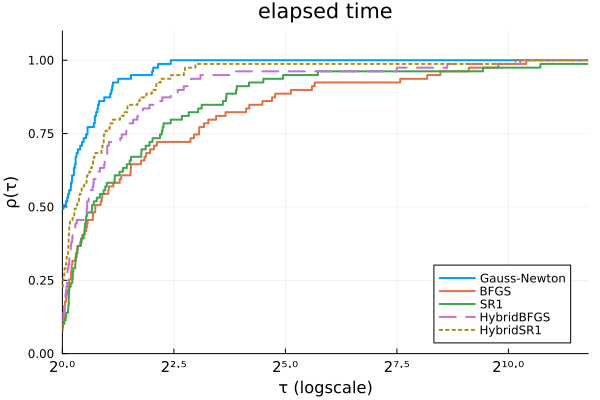

In [8]:
display(plt_time)

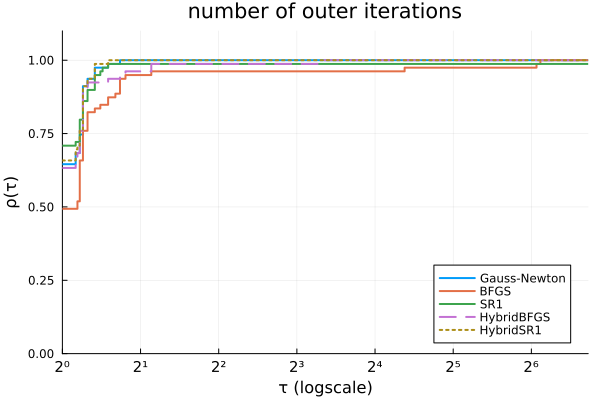

In [9]:
display(plt_nouter)

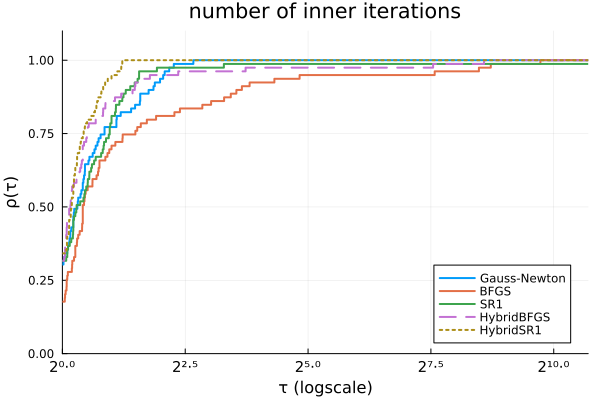

In [10]:
display(plt_ninner)

## Focus on Gauss-Newton versus structured hybrid updates (SR1 and BFGS)

In [11]:
# Comparison of Hybrid-Hessian approaches vs. Gauss-Newon
solvers_df = [df_gn, df_hybrid_bfgs, df_hybrid_sr1]
solvers = ["Gauss-Newton", "HybridBFGS", "HybridSR1"]

# Elapsed time
T = make_traulls_table(:elapsed_time, solvers_df)
plt_traulls_time = performance_profile(PlotsBackend(), T, solvers, 
        c = :black, linestyles = [:solid, :dash, :dot], lw=2, 
    legend=:bottomright, xaxis = "τ (logscale)", yaxis = "ρ(τ)", title = "elapsed time")

# Number of residuals evaluation
T = make_traulls_table(:neval_residual, solvers_df)
plt_traulls_neval_res = performance_profile(PlotsBackend(), T, solvers, 
        c = :black, linestyles = [:solid, :dash, :dot], lw=2, 
    legend=:bottomright, xaxis = "τ (logscale)", yaxis = "ρ(τ)", title = "number of residuals evaluations")

# Number of gradient evaluation
T = make_traulls_table(:neval_grad, solvers_df)
plt_traulls_neval_grad = performance_profile(PlotsBackend(), T, solvers, 
       c = :black, linestyles = [:solid, :dash, :dot], lw=2, 
    legend=:bottomright, xaxis = "τ (logscale)", yaxis = "ρ(τ)", title = "number of gradient evaluations");

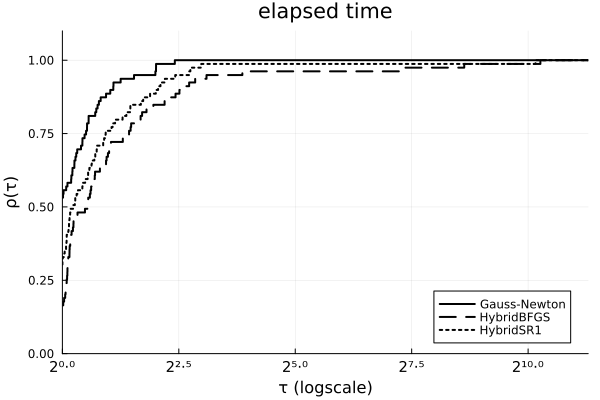

In [12]:
display(plt_traulls_time)

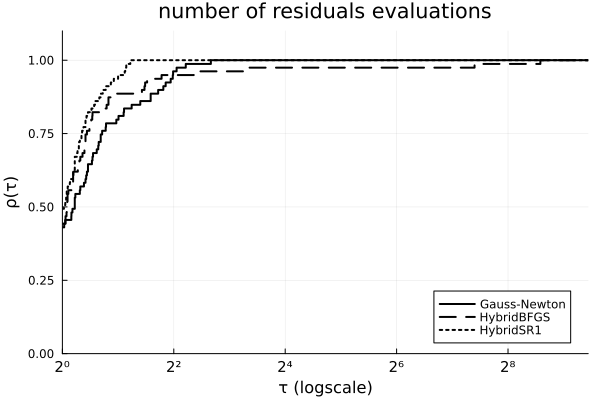

In [13]:
display(plt_traulls_neval_res)

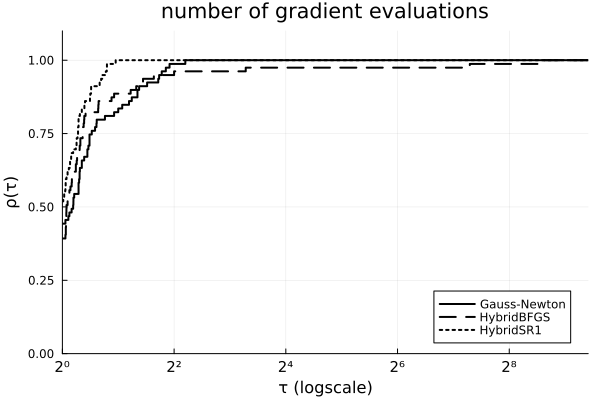

In [14]:
display(plt_traulls_neval_grad)

# Comparison against Percival and IPOPT

In [15]:
df_ipopt = CSV.read("results/ipopt.csv", DataFrame)
df_percival = CSV.read("results/percival.csv", DataFrame);

In [16]:
solvers = ["Traulls.jl", "Ipopt.jl", "Percival.jl"]

function make_performance_table(stats_traulls, stats_ipopt, stats_percival, metric)
    T = zeros(nrow(stats_traulls), 3)

    for (i, row) in enumerate(eachrow(stats_traulls))
        T[i, 1] = row[:status] == "first_order_critical" ? row[metric] : Inf
    end

    for (i, row) in enumerate(eachrow(stats_ipopt))
        T[i, 2] = row[:status] == "first_order" ? row[metric] : Inf
    end

    for (i, row) in enumerate(eachrow(stats_percival))
        T[i, 3] = row[:status] == "first_order" ? row[metric] : Inf
    end

    return T
end

performance_table(metric) = make_performance_table(df_hybrid_sr1, df_ipopt, df_percival, metric)

performance_table (generic function with 1 method)

In [17]:
# Elapsed time
T = performance_table(:elapsed_time)
plt_elapsed_time = performance_profile(PlotsBackend(), T, solvers, 
        c = :black, linestyles = [:dot, :solid, :dash], lw=2, 
    legend=:bottomright, xaxis = "τ (logscale)", yaxis = "ρ(τ)", title = "elapsed time")

# Residual evaluation
T = performance_table(:neval_residual)
plt_neval_res = performance_profile(PlotsBackend(), T, solvers, 
        c = :black, linestyles = [:dot, :solid, :dash], lw=2, 
    legend=:bottomright, xaxis = "τ (logscale)", yaxis = "ρ(τ)", title = "number of residuals evaluations")

# Gradient evaluations
T = performance_table(:neval_grad)
plt_neval_grad = performance_profile(PlotsBackend(), T, solvers, 
        c = :black, linestyles = [:dot, :solid, :dash], lw=2, 
    legend=:bottomright, xaxis = "τ (logscale)", yaxis = "ρ(τ)", title = "number of gradient evaluations");

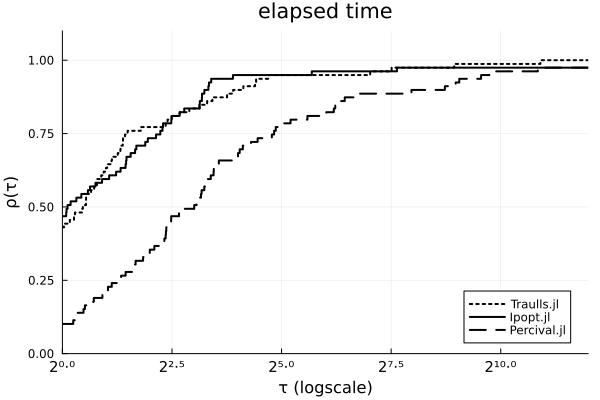

In [18]:
display(plt_elapsed_time)

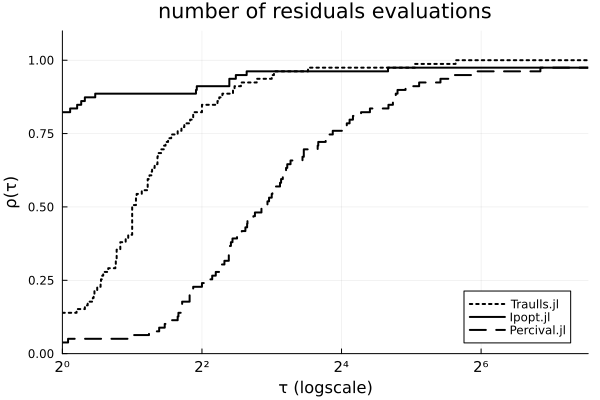

In [19]:
display(plt_neval_res)

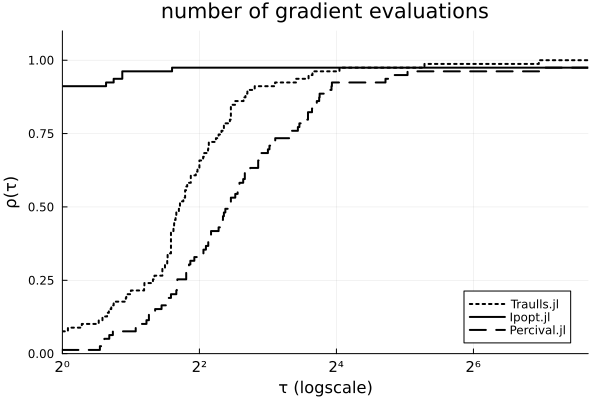

In [20]:
display(plt_neval_grad)